In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
groq_api_key=os.getenv("GROQ_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [15]:
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

@tool
def search(query: str):
    """search the web for a query and return the results"""
    tavily=TavilySearchResults()
    result=tavily.invoke(query)
    return f"Result for {query} is: \n{result}"

@tool
def multiply(x: int, y: int) -> int:
    """Multiplies two numbers."""
    return x * y


In [16]:
tools = [search, multiply]
tools

[StructuredTool(name='search', description='search the web for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x000001D4BB5376D0>),
 StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000001D4BB5375B0>)]

In [38]:
model="openai/gpt-oss-120b"

In [39]:
from langchain_groq import ChatGroq
llm = ChatGroq(api_key=groq_api_key, model=model)

In [40]:
llm_with_tools = llm.bind_tools(tools)

In [41]:
tool_mapping={tool.name:tool for tool in tools}

In [42]:
from typing import TypedDict, Sequence, Annotated
import operator
from langchain_core.messages import BaseMessage

class AgentState(TypedDict):
    """State of the agent"""
    messages: Annotated[Sequence[BaseMessage],operator.add]

In [43]:
def ai_assistant(state: AgentState):
    messages=state["messages"]
    question = messages[-1]
    response = llm_with_tools.invoke(question)
    return {"messages":[response]}

In [44]:
def router(state: AgentState):
    tool_calls=state["messages"][-1].tool_calls
    
    if len(tool_calls)>0:
        return "tool"
    else:
        return "end"

In [45]:
def invoke_tool(state: AgentState):
    tool_details=state["messages"][-1].tool_calls
    
    if tool_details is None:
        return Exception("No tool calls found in the last message.")
    print(f"Tool selected: {tool_details[0]['name']}")
    
    if tool_details[0]['name'] == "search":
        response = input(prompt="[yes/no] do you want to continue with this expensive web search")
        if response.lower() == "no":
            print("User chose not to continue with the web search. Aborting tool invocation.")
            return {"messages":[llm.invoke("User chose not to continue with the web search. Aborting tool invocation.")]}
    tool=tool_mapping["search"]
    result=tool.invoke(tool_details[0]['args'])
    return {"messages":[result]}

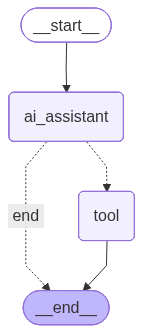

In [46]:
from langgraph.graph import StateGraph, START, END
graph = StateGraph(AgentState)
graph.add_node("ai_assistant", ai_assistant)
graph.add_edge(START, "ai_assistant")
graph.add_node("tool", invoke_tool)
graph.add_conditional_edges(
    "ai_assistant",
    router,
    {
        "tool": "tool",
        "end": END
    }
)
graph.add_edge("tool",END)
app=graph.compile()
app

In [47]:
response = app.invoke({"messages":["What is the multiplication of 5 and 20?"]})
response

{'messages': ['What is the multiplication of 5 and 20?',
  AIMessage(content='The product of\u202f5\u202fand\u202f20\u202fis **100**.', additional_kwargs={'reasoning_content': 'The user asks: "What is the multiplication of 5 and 20?" That\'s simple: 5*20 = 100. No need for tool.'}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 158, 'total_tokens': 215, 'completion_time': 0.118878864, 'completion_tokens_details': {'reasoning_tokens': 33}, 'prompt_time': 0.005997763, 'prompt_tokens_details': None, 'queue_time': 0.292840914, 'total_time': 0.124876627}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d63b2695ba', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f5230-c801-71b2-b7c4-549341fb3d02-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 158, 'output_tokens': 57, 'total_tokens': 215, 'output_token_details': {'reasoning': 33}})]}

In [48]:
response = app.invoke({"messages":["What is the current gdp of the india?"]})

Tool selected: search


C:\Users\hp\AppData\Local\Temp\ipykernel_14052\2909310446.py:7: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily=TavilySearchResults()


In [ ]:
response # with input 'yes'

{'messages': ['What is the current gdp of the india?',
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the current gdp of the india?" Likely wants current GDP figure. Need up-to-date info. Should browse web. Use search.', 'tool_calls': [{'id': 'fc_67061366-de6e-4522-b72d-2487d86786a8', 'function': {'arguments': '{"query":"current GDP of India 2024"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 157, 'total_tokens': 225, 'completion_time': 0.148650675, 'completion_tokens_details': {'reasoning_tokens': 36}, 'prompt_time': 0.006299752, 'prompt_tokens_details': None, 'queue_time': 0.287173554, 'total_time': 0.154950427}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5781dfb07c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f5231-9fc1-7ee2-8114-9adc59bfa708-0', tool_calls=[{'name': 'sea

In [50]:
response = app.invoke({"messages":["What is the current gdp of the india?"]})
response # with input 'no'

Tool selected: search
User chose not to continue with the web search. Aborting tool invocation.


{'messages': ['What is the current gdp of the india?',
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the current gdp of the india?" Likely wants current GDP of India. Need up-to-date data. As of 2026? Need to search web. Use search tool.', 'tool_calls': [{'id': 'fc_eb02d997-cc08-4c3d-9583-6a20987c34f0', 'function': {'arguments': '{"query":"India current GDP 2026"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 76, 'prompt_tokens': 157, 'total_tokens': 233, 'completion_time': 0.158531825, 'completion_tokens_details': {'reasoning_tokens': 45}, 'prompt_time': 0.036031841, 'prompt_tokens_details': None, 'queue_time': 0.294315464, 'total_time': 0.194563666}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e1a78f200e', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f5234-9c4f-7883-bba2-f3db2f1b6b71-0', tool_cal

Inbuilt Humaninloop

In [51]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

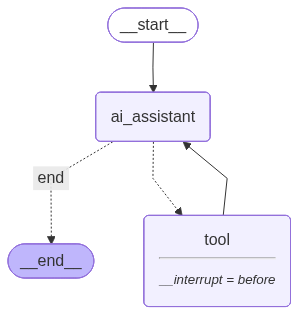

In [68]:
from langgraph.graph import StateGraph, START, END
graph = StateGraph(AgentState)
graph.add_node("ai_assistant", ai_assistant)
graph.add_edge(START, "ai_assistant")
graph.add_node("tool", invoke_tool)
graph.add_conditional_edges(
    "ai_assistant",
    router,
    {
        "tool": "tool",
        "end": END
    }
)
graph.add_edge("tool","ai_assistant")
app=graph.compile(checkpointer=memory, interrupt_before=["tool"])
app

In [69]:
config={"configurable":{"thread_id":"1"}}
response = app.invoke({"messages":["What is the current gdp of the india?"]}, config=config)
response

{'messages': ['What is the current gdp of the india?',
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the current gdp of the india?" Likely they want the current GDP of India. Need up-to-date figure. As of date July 2026, we need current GDP. Need to browse. Use search.', 'tool_calls': [{'id': 'fc_40e72929-0fd7-4972-8122-7dfbbc653881', 'function': {'arguments': '{"query":"India GDP 2026 current GDP"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 157, 'total_tokens': 241, 'completion_time': 0.179631745, 'completion_tokens_details': {'reasoning_tokens': 52}, 'prompt_time': 0.005983691, 'prompt_tokens_details': None, 'queue_time': 0.281595366, 'total_time': 0.185615436}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_b1dd3e7a63', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f523c-07e9

In [70]:
snapshot=app.get_state(config)
snapshot

StateSnapshot(values={'messages': ['What is the current gdp of the india?', AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the current gdp of the india?" Likely they want the current GDP of India. Need up-to-date figure. As of date July 2026, we need current GDP. Need to browse. Use search.', 'tool_calls': [{'id': 'fc_40e72929-0fd7-4972-8122-7dfbbc653881', 'function': {'arguments': '{"query":"India GDP 2026 current GDP"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 157, 'total_tokens': 241, 'completion_time': 0.179631745, 'completion_tokens_details': {'reasoning_tokens': 52}, 'prompt_time': 0.005983691, 'prompt_tokens_details': None, 'queue_time': 0.281595366, 'total_time': 0.185615436}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_b1dd3e7a63', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc

In [71]:
last_message=snapshot.values["messages"][-1]
tool_details=last_message.tool_calls
tool_details

[{'name': 'search',
  'args': {'query': 'India GDP 2026 current GDP'},
  'id': 'fc_910203a5-d07c-4c5b-a01a-da3d3b0d78bb',
  'type': 'tool_call'}]

In [73]:
if tool_details[0]["name"]== "search":
    user_input=input(prompt=f"[yes/no] do you want to continue with {tool_details[0]['name']}?").lower()
    if user_input=="no":
        print("web tool discarded")
        raise Exception("Web tool discarded by the user.")
    else:
        response=app.invoke(None,config)
        print(response)
else:
    response=app.invoke(None,config)
    print(response)

Tool selected: search
{'messages': ['What is the current gdp of the india?', AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the current gdp of the india?" Likely they want the current GDP of India. Need up-to-date figure. As of date July 2026, we need current GDP. Need to browse. Use search.', 'tool_calls': [{'id': 'fc_40e72929-0fd7-4972-8122-7dfbbc653881', 'function': {'arguments': '{"query":"India GDP 2026 current GDP"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 157, 'total_tokens': 241, 'completion_time': 0.179631745, 'completion_tokens_details': {'reasoning_tokens': 52}, 'prompt_time': 0.005983691, 'prompt_tokens_details': None, 'queue_time': 0.281595366, 'total_time': 0.185615436}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_b1dd3e7a63', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='l

In [74]:
response

{'messages': ['What is the current gdp of the india?',
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the current gdp of the india?" Likely they want the current GDP of India. Need up-to-date figure. As of date July 2026, we need current GDP. Need to browse. Use search.', 'tool_calls': [{'id': 'fc_40e72929-0fd7-4972-8122-7dfbbc653881', 'function': {'arguments': '{"query":"India GDP 2026 current GDP"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 157, 'total_tokens': 241, 'completion_time': 0.179631745, 'completion_tokens_details': {'reasoning_tokens': 52}, 'prompt_time': 0.005983691, 'prompt_tokens_details': None, 'queue_time': 0.281595366, 'total_time': 0.185615436}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_b1dd3e7a63', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f523c-07e9

In [75]:
print(response["messages"][-1].content)

The latest estimates put **India’s nominal (current‑price) GDP in 2026 at roughly $4.15 trillion USD** (about $4,153 billion).  

- **Source**: International Monetary Fund (World Economic Outlook, April 2026) – also reflected on Worldometers and several secondary aggregators.  
- **Key accompanying figures** (IMF):
  * **GDP growth rate (2026)**: 6.5 %  
  * **Population (2026)**: ≈ 1.48 billion  
  * **GDP per capita (current prices)**: ≈ $2,813  

So, the current‑price (nominal) GDP for India in 2026 is **$4.15 trillion**.


In [76]:
response = app.invoke({"messages":["What is the current gdp of the Japan?"]}, config=config)
response

{'messages': ['What is the current gdp of the india?',
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the current gdp of the india?" Likely they want the current GDP of India. Need up-to-date figure. As of date July 2026, we need current GDP. Need to browse. Use search.', 'tool_calls': [{'id': 'fc_40e72929-0fd7-4972-8122-7dfbbc653881', 'function': {'arguments': '{"query":"India GDP 2026 current GDP"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 157, 'total_tokens': 241, 'completion_time': 0.179631745, 'completion_tokens_details': {'reasoning_tokens': 52}, 'prompt_time': 0.005983691, 'prompt_tokens_details': None, 'queue_time': 0.281595366, 'total_time': 0.185615436}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_b1dd3e7a63', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f523c-07e9

In [77]:
## getting tool_call_id and updating state manually
snapshot=app.get_state(config)
last_message=snapshot.values["messages"][-1]
tool_call_id=last_message.tool_calls[0]["id"]
tool_call_id

'fc_ce8d5d49-1ae3-4571-bd6d-28170860403a'

In [80]:
from langchain_core.messages import ToolMessage, AIMessage
new_message = [
    ToolMessage("GDP of Japan is 4.1 Trillion USD.", tool_call_id=tool_call_id),
    AIMessage(content="GDP is 4.1 Trillion USD.")
]

In [81]:
app.update_state(config, {"messages":new_message})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f17d50a-2675-6e49-800f-80643766b13e'}}

In [82]:
app.get_state(config).values["messages"][-1]

AIMessage(content='GDP is 4.1 Trillion USD.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])